
CORRELACIÓN CON VENTAS:
Ventas                1.000000
Solicitud_Aprobada    0.822709
Formalizado           0.606540
Prueba_Manejo         0.535350
Leads_Generados       0.486712
Solicitud_Generada    0.460497
Leads_Efectivos       0.351173
Cita_Efectiva         0.342661
Cita_Programada       0.335212
Name: Ventas, dtype: float64

REGRESIÓN 1 - RESULTADOS COMPLETOS

R²:
0.7053

Coeficiente de correlación múltiple:
0.8398

R² ajustado:
0.6146

p-value global:
0.0019874067517125053

Intercepto:
4.6816

Coeficientes:
             Variable  Coeficiente
0       Cita_Efectiva    -0.004079
1       Prueba_Manejo     0.060203
2  Solicitud_Aprobada     0.605570
3         Formalizado     0.033095

P-values por variable:
const                 0.445185
Cita_Efectiva         0.819095
Prueba_Manejo         0.302850
Solicitud_Aprobada    0.018771
Formalizado           0.923342
dtype: float64

ECUACIÓN:
Ventas = 4.6816 - 0.0041(Cita_Efectiva) + 0.0602(Prueba_Manejo) + 0.6056(Solicitud_Aprobada) + 0.03

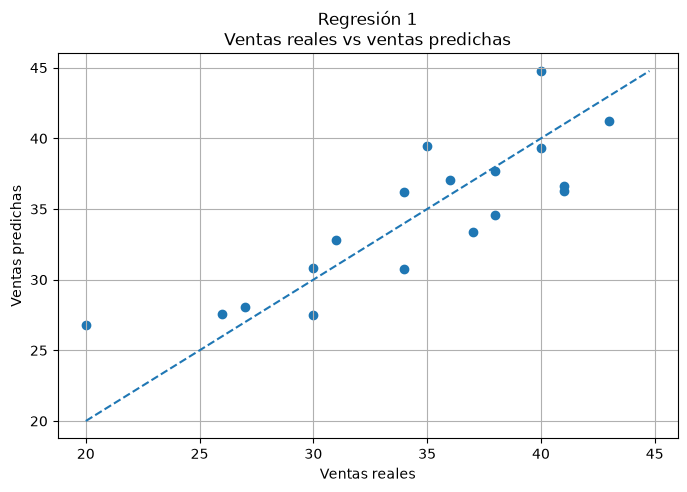

In [3]:
# ============================================================
# REGRESIÓN 1
# ETAPAS DEL FUNNEL -> VENTAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm


# ============================================================
# 1. CARGAR BASE
# ============================================================

df = pd.read_csv("FUNNEL.csv")


# ============================================================
# 2. IDENTIFICAR MESES
# ============================================================

meses = []

for i, valor in enumerate(df.iloc[:, 0]):

    if pd.isna(valor):
        continue

    valor = str(valor).strip()

    if valor.startswith("Funnel "):
        meses.append((i, valor))


# ============================================================
# 3. EXTRAER DATOS REALES DE CADA MES
# ============================================================

registros = []

for posicion in range(len(meses)):

    fila_inicio = meses[posicion][0]
    nombre_mes = meses[posicion][1].replace("Funnel ", "").strip()

    if posicion < len(meses) - 1:
        fila_fin = meses[posicion + 1][0]
    else:
        fila_fin = len(df)

    bloque = df.iloc[fila_inicio:fila_fin, 0:3].copy()

    bloque.columns = [
        "Item",
        "Objetivo",
        "Real"
    ]

    bloque = bloque.dropna(subset=["Item"])

    bloque["Item"] = (
        bloque["Item"]
        .astype(str)
        .str.strip()
    )

    bloque["Real"] = (
        bloque["Real"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    bloque["Real"] = pd.to_numeric(
        bloque["Real"],
        errors="coerce"
    )

    registro = {
        "Mes": nombre_mes
    }

    variables = [
        "Ventas",
        "Leads generados",
        "Leads efectivos",
        "Cita programada",
        "Cita efectiva",
        "Prueba de manejo",
        "Solicitud de crédito generada",
        "Solicitud de crédito aprobada",
        "Formalizado",
        "Cerrador"
    ]

    for variable in variables:

        coincidencia = bloque[
            bloque["Item"].str.lower()
            == variable.lower()
        ]

        if len(coincidencia) > 0:
            registro[variable] = coincidencia.iloc[0]["Real"]

    registros.append(registro)


# ============================================================
# 4. CREAR BASE LIMPIA
# ============================================================

funnel = pd.DataFrame(registros)


# ============================================================
# 5. UNIFICAR FORMALIZADO Y CERRADOR
# ============================================================

if "Formalizado" not in funnel.columns:
    funnel["Formalizado"] = np.nan

if "Cerrador" not in funnel.columns:
    funnel["Cerrador"] = np.nan

funnel["Formalizado"] = (
    funnel["Formalizado"]
    .fillna(funnel["Cerrador"])
)

funnel = funnel.drop(
    columns=["Cerrador"],
    errors="ignore"
)


# ============================================================
# 6. RENOMBRAR COLUMNAS
# ============================================================

funnel = funnel.rename(columns={

    "Leads generados":
        "Leads_Generados",

    "Leads efectivos":
        "Leads_Efectivos",

    "Cita programada":
        "Cita_Programada",

    "Cita efectiva":
        "Cita_Efectiva",

    "Prueba de manejo":
        "Prueba_Manejo",

    "Solicitud de crédito generada":
        "Solicitud_Generada",

    "Solicitud de crédito aprobada":
        "Solicitud_Aprobada"
})


# ============================================================
# 7. CORRELACIONES
# ============================================================

variables_numericas = funnel.select_dtypes(include=np.number)

correlaciones = variables_numericas.corr()

print("\nCORRELACIÓN CON VENTAS:")
print(
    correlaciones["Ventas"]
    .sort_values(ascending=False)
)


# ============================================================
# 8. DEFINIR MODELO
# ============================================================

Variable_y = "Ventas"

Variables_x = [
    "Cita_Efectiva",
    "Prueba_Manejo",
    "Solicitud_Aprobada",
    "Formalizado"
]

X = funnel[Variables_x]
y = funnel[Variable_y]


# ============================================================
# 9. REGRESIÓN
# ============================================================

modelo1 = LinearRegression()

modelo1.fit(
    X,
    y
)

y_pred1 = modelo1.predict(X)


# ============================================================
# 10. R² Y CORRELACIÓN MÚLTIPLE
# ============================================================

r2_1 = modelo1.score(X, y)

correlacion_multiple1 = np.sqrt(r2_1)


# ============================================================
# 11. COEFICIENTES Y ECUACIÓN
# ============================================================

coeficientes1 = pd.DataFrame({
    "Variable": Variables_x,
    "Coeficiente": modelo1.coef_
})

ecuacion1 = f"Ventas = {modelo1.intercept_:.4f}"

for variable, coef in zip(
    Variables_x,
    modelo1.coef_
):

    if coef >= 0:
        ecuacion1 += f" + {coef:.4f}({variable})"
    else:
        ecuacion1 += f" - {abs(coef):.4f}({variable})"


# ============================================================
# 12. OLS
# ============================================================

X_ols1 = sm.add_constant(X)

modelo_ols1 = sm.OLS(
    y,
    X_ols1
).fit()


# ============================================================
# 13. TODO EL RESUMEN JUNTO
# ============================================================

print("\n========================================")
print("REGRESIÓN 1 - RESULTADOS COMPLETOS")
print("========================================")

print("\nR²:")
print(round(r2_1, 4))

print("\nCoeficiente de correlación múltiple:")
print(round(correlacion_multiple1, 4))

print("\nR² ajustado:")
print(round(modelo_ols1.rsquared_adj, 4))

print("\np-value global:")
print(modelo_ols1.f_pvalue)

print("\nIntercepto:")
print(round(modelo1.intercept_, 4))

print("\nCoeficientes:")
print(coeficientes1)

print("\nP-values por variable:")
print(modelo_ols1.pvalues)

print("\nECUACIÓN:")
print(ecuacion1)

print("\nRESUMEN OLS COMPLETO:")
print(modelo_ols1.summary())


# ============================================================
# 14. TABLA REAL VS PREDICHO
# ============================================================

resultados1 = pd.DataFrame({
    "Mes": funnel["Mes"],
    "Ventas_Reales": y,
    "Ventas_Predichas": y_pred1
})

print("\nVENTAS REALES VS PREDICHAS:")
print(resultados1)


# ============================================================
# 15. GRÁFICA 1
# VENTAS REALES VS PREDICHAS
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    resultados1["Ventas_Reales"],
    resultados1["Ventas_Predichas"]
)

minimo = min(
    resultados1["Ventas_Reales"].min(),
    resultados1["Ventas_Predichas"].min()
)

maximo = max(
    resultados1["Ventas_Reales"].max(),
    resultados1["Ventas_Predichas"].max()
)

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")

plt.title(
    "Regresión 1\n"
    "Ventas reales vs ventas predichas"
)

plt.grid()
plt.show()



BASE PARA REGRESIÓN 2:
                Mes  Mes_Num  Ventas  Solicitud_Aprobada
0        Enero 2025        1    26.0                29.0
1      Febrero 2025        2    20.0                27.0
2        Marzo 2025        3    30.0                30.0
3        Abril 2025        4    30.0                35.0
4         Mayo 2025        5    34.0                40.0
5        Junio 2025        6    40.0                46.0
6        Julio 2025        7    36.0                41.0
7       Agosto 2025        8    27.0                27.0
8   Septiembre 2025        9    38.0                43.0
9      Octubre 2025       10    40.0                51.0
10   Noviembre 2025       11    43.0                49.0
11   Diciembre 2025       12    34.0                31.0
12       Enero 2026       13    38.0                35.0
13     Febrero 2026       14    31.0                37.0
14       Marzo 2026       15    41.0                41.0
15       Abril 2026       16    41.0                41.0
16     

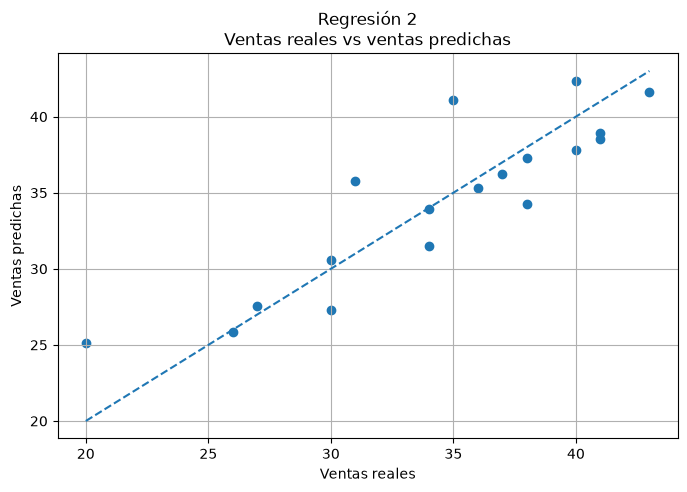

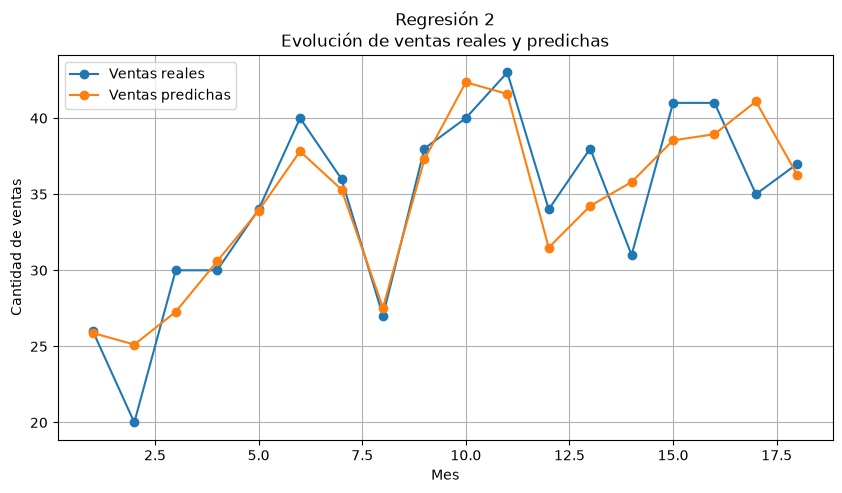

In [2]:
# ============================================================
# REGRESIÓN 2
# TIEMPO + SOLICITUD APROBADA -> VENTAS
# ============================================================


# ============================================================
# 1. CREAR VARIABLE DE TIEMPO
# ============================================================

funnel["Mes_Num"] = range(
    1,
    len(funnel) + 1
)

print("\nBASE PARA REGRESIÓN 2:")

print(
    funnel[
        [
            "Mes",
            "Mes_Num",
            "Ventas",
            "Solicitud_Aprobada"
        ]
    ]
)


# ============================================================
# 2. DEFINIR VARIABLES
# ============================================================

Variable_y2 = "Ventas"

Variables_x2 = [
    "Mes_Num",
    "Solicitud_Aprobada"
]

X2 = funnel[Variables_x2]
y2 = funnel[Variable_y2]


# ============================================================
# 3. REGRESIÓN
# ============================================================

modelo2 = LinearRegression()

modelo2.fit(
    X2,
    y2
)

y_pred2 = modelo2.predict(X2)


# ============================================================
# 4. R² Y CORRELACIÓN MÚLTIPLE
# ============================================================

r2_2 = modelo2.score(
    X2,
    y2
)

correlacion_multiple2 = np.sqrt(r2_2)


# ============================================================
# 5. COEFICIENTES
# ============================================================

coeficientes2 = pd.DataFrame({
    "Variable":
        Variables_x2,

    "Coeficiente":
        modelo2.coef_
})


# ============================================================
# 6. ECUACIÓN
# ============================================================

ecuacion2 = (
    f"Ventas = {modelo2.intercept_:.4f}"
)

for variable, coef in zip(
    Variables_x2,
    modelo2.coef_
):

    if coef >= 0:
        ecuacion2 += (
            f" + {coef:.4f}"
            f"({variable})"
        )
    else:
        ecuacion2 += (
            f" - {abs(coef):.4f}"
            f"({variable})"
        )


# ============================================================
# 7. OLS
# ============================================================

X_ols2 = sm.add_constant(X2)

modelo_ols2 = sm.OLS(
    y2,
    X_ols2
).fit()


# ============================================================
# 8. RESULTADOS COMPLETOS
# ============================================================

print("\n========================================")
print("REGRESIÓN 2 - RESULTADOS COMPLETOS")
print("========================================")

print("\nR²:")
print(round(r2_2, 4))

print("\nCoeficiente de correlación múltiple:")
print(round(correlacion_multiple2, 4))

print("\nR² ajustado:")
print(round(modelo_ols2.rsquared_adj, 4))

print("\np-value global:")
print(modelo_ols2.f_pvalue)

print("\nIntercepto:")
print(round(modelo2.intercept_, 4))

print("\nCoeficientes:")
print(coeficientes2)

print("\nP-values:")
print(modelo_ols2.pvalues)

print("\nECUACIÓN:")
print(ecuacion2)

print("\nRESUMEN OLS COMPLETO:")
print(modelo_ols2.summary())


# ============================================================
# 9. TABLA DE RESULTADOS
# ============================================================

resultados2 = pd.DataFrame({
    "Mes":
        funnel["Mes"],

    "Mes_Num":
        funnel["Mes_Num"],

    "Ventas_Reales":
        y2,

    "Ventas_Predichas":
        y_pred2
})

print("\nVENTAS REALES VS PREDICHAS:")
print(resultados2)


# ============================================================
# 10. GRÁFICA 1
# VENTAS REALES VS PREDICHAS
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    resultados2["Ventas_Reales"],
    resultados2["Ventas_Predichas"]
)

minimo = min(
    resultados2["Ventas_Reales"].min(),
    resultados2["Ventas_Predichas"].min()
)

maximo = max(
    resultados2["Ventas_Reales"].max(),
    resultados2["Ventas_Predichas"].max()
)

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

plt.xlabel(
    "Ventas reales"
)

plt.ylabel(
    "Ventas predichas"
)

plt.title(
    "Regresión 2\n"
    "Ventas reales vs ventas predichas"
)

plt.grid()
plt.show()


# ============================================================
# 11. GRÁFICA 2
# EVOLUCIÓN POR MES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    funnel["Mes_Num"],
    funnel["Ventas"],
    marker="o",
    label="Ventas reales"
)

plt.plot(
    funnel["Mes_Num"],
    y_pred2,
    marker="o",
    label="Ventas predichas"
)

plt.xlabel(
    "Mes"
)

plt.ylabel(
    "Cantidad de ventas"
)

plt.title(
    "Regresión 2\n"
    "Evolución de ventas reales y predichas"
)

plt.legend()
plt.grid()
plt.show()


DATOS PARA LA REGRESIÓN 3:
                Mes  Mes_Num  Cita_Efectiva  Prueba_Manejo  Solicitud_Aprobada
0        Enero 2025        1          109.0           86.0                29.0
1      Febrero 2025        2          101.0           97.0                27.0
2        Marzo 2025        3          140.0           77.0                30.0
3        Abril 2025        4          114.0           81.0                35.0
4         Mayo 2025        5          157.0          121.0                40.0
5        Junio 2025        6          177.0          111.0                46.0
6        Julio 2025        7          193.0          127.0                41.0
7       Agosto 2025        8          194.0          123.0                27.0
8   Septiembre 2025        9          212.0          116.0                43.0
9      Octubre 2025       10          220.0          154.0                51.0
10   Noviembre 2025       11          225.0          116.0                49.0
11   Diciembre 2025     

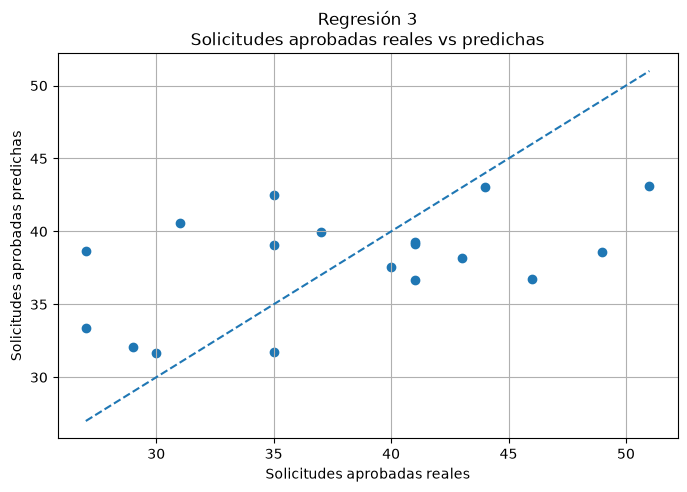

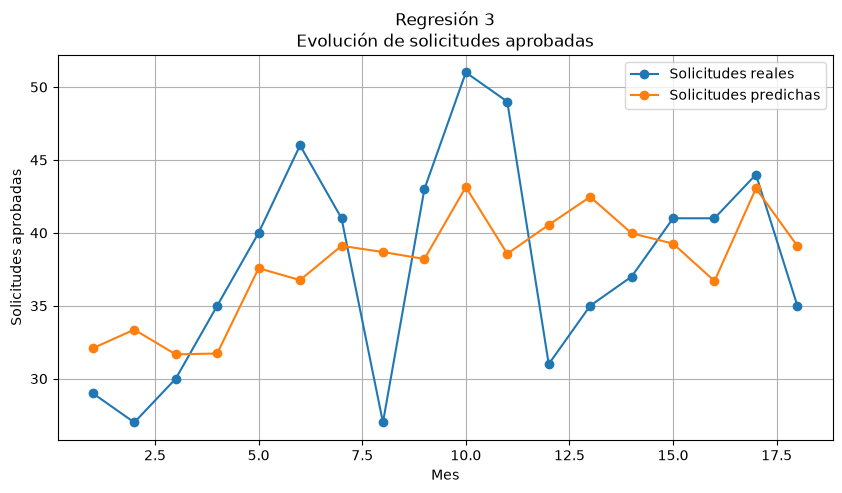

In [4]:
# ============================================================
# REGRESIÓN 3
# TIEMPO + CITA EFECTIVA + PRUEBA DE MANEJO
# -> SOLICITUDES DE CRÉDITO APROBADAS
# ============================================================


# ============================================================
# 1. ASEGURAR VARIABLE DE TIEMPO
# ============================================================

# Si todavía no existe Mes_Num, la creamos

if "Mes_Num" not in funnel.columns:

    funnel["Mes_Num"] = range(
        1,
        len(funnel) + 1
    )


# ============================================================
# 2. VER DATOS QUE VAMOS A UTILIZAR
# ============================================================

print("\nDATOS PARA LA REGRESIÓN 3:")

print(
    funnel[
        [
            "Mes",
            "Mes_Num",
            "Cita_Efectiva",
            "Prueba_Manejo",
            "Solicitud_Aprobada"
        ]
    ]
)


# ============================================================
# 3. DEFINIR VARIABLES
# ============================================================

# Variable que queremos explicar
Variable_y3 = "Solicitud_Aprobada"


# Variables que podrían explicarla
Variables_x3 = [
    "Mes_Num",
    "Cita_Efectiva",
    "Prueba_Manejo"
]


X3 = funnel[Variables_x3]

y3 = funnel[Variable_y3]


# ============================================================
# 4. CORRELACIONES
# ============================================================

variables_reg3 = funnel[
    [
        "Solicitud_Aprobada",
        "Mes_Num",
        "Cita_Efectiva",
        "Prueba_Manejo"
    ]
]

correlaciones3 = variables_reg3.corr()


print("\n========================================")
print("CORRELACIONES REGRESIÓN 3")
print("========================================")

print(correlaciones3)


print(
    "\nCorrelación con Solicitud_Aprobada:"
)

print(
    correlaciones3[
        "Solicitud_Aprobada"
    ].sort_values(
        ascending=False
    )
)


# ============================================================
# 5. CREAR MODELO DE REGRESIÓN MÚLTIPLE
# ============================================================

modelo3 = LinearRegression()


modelo3.fit(
    X3,
    y3
)


# ============================================================
# 6. REALIZAR PREDICCIONES
# ============================================================

solicitudes_predichas = modelo3.predict(
    X3
)


# ============================================================
# 7. R²
# ============================================================

r2_3 = modelo3.score(
    X3,
    y3
)


correlacion_multiple3 = np.sqrt(
    r2_3
)


# ============================================================
# 8. COEFICIENTES
# ============================================================

coeficientes3 = pd.DataFrame({

    "Variable":
        Variables_x3,

    "Coeficiente":
        modelo3.coef_

})


# ============================================================
# 9. ECUACIÓN
# ============================================================

ecuacion3 = (
    f"Solicitud_Aprobada = "
    f"{modelo3.intercept_:.4f}"
)


for variable, coef in zip(
    Variables_x3,
    modelo3.coef_
):

    if coef >= 0:

        ecuacion3 += (
            f" + {coef:.4f}"
            f"({variable})"
        )

    else:

        ecuacion3 += (
            f" - {abs(coef):.4f}"
            f"({variable})"
        )


# ============================================================
# 10. MODELO OLS
# ============================================================

X_ols3 = sm.add_constant(
    X3
)


modelo_ols3 = sm.OLS(
    y3,
    X_ols3
).fit()


# ============================================================
# 11. MOSTRAR TODOS LOS RESULTADOS JUNTOS
# ============================================================

print("\n========================================")
print("REGRESIÓN 3 - RESULTADOS COMPLETOS")
print("========================================")


print(
    "\nVariable dependiente:"
)

print(
    "Solicitud_Aprobada"
)


print(
    "\nVariables independientes:"
)

print(
    Variables_x3
)


print(
    "\nR²:"
)

print(
    round(
        r2_3,
        4
    )
)


print(
    "\nCoeficiente de correlación múltiple:"
)

print(
    round(
        correlacion_multiple3,
        4
    )
)


print(
    "\nR² ajustado:"
)

print(
    round(
        modelo_ols3.rsquared_adj,
        4
    )
)


print(
    "\np-value global:"
)

print(
    modelo_ols3.f_pvalue
)


print(
    "\nIntercepto:"
)

print(
    round(
        modelo3.intercept_,
        4
    )
)


print(
    "\nCoeficientes:"
)

print(
    coeficientes3
)


print(
    "\nP-values por variable:"
)

print(
    modelo_ols3.pvalues
)


print(
    "\nECUACIÓN:"
)

print(
    ecuacion3
)


print(
    "\nRESUMEN OLS COMPLETO:"
)

print(
    modelo_ols3.summary()
)


# ============================================================
# 12. TABLA REAL VS PREDICHO
# ============================================================

resultados3 = pd.DataFrame({

    "Mes":
        funnel["Mes"],

    "Mes_Num":
        funnel["Mes_Num"],

    "Solicitud_Real":
        y3,

    "Solicitud_Predicha":
        solicitudes_predichas

})


print(
    "\nSOLICITUDES APROBADAS"
    " REALES VS PREDICHAS:"
)

print(
    resultados3
)


# ============================================================
# 13. GRÁFICA 1
# SOLICITUDES REALES VS PREDICHAS
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.scatter(
    resultados3["Solicitud_Real"],
    resultados3["Solicitud_Predicha"]
)


minimo3 = min(
    resultados3["Solicitud_Real"].min(),
    resultados3["Solicitud_Predicha"].min()
)


maximo3 = max(
    resultados3["Solicitud_Real"].max(),
    resultados3["Solicitud_Predicha"].max()
)


plt.plot(
    [minimo3, maximo3],
    [minimo3, maximo3],
    linestyle="--"
)


plt.xlabel(
    "Solicitudes aprobadas reales"
)


plt.ylabel(
    "Solicitudes aprobadas predichas"
)


plt.title(
    "Regresión 3\n"
    "Solicitudes aprobadas reales vs predichas"
)


plt.grid()

plt.show()


# ============================================================
# 14. GRÁFICA 2
# EVOLUCIÓN DE SOLICITUDES APROBADAS
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    funnel["Mes_Num"],
    y3,
    marker="o",
    label="Solicitudes reales"
)


plt.plot(
    funnel["Mes_Num"],
    solicitudes_predichas,
    marker="o",
    label="Solicitudes predichas"
)


plt.xlabel(
    "Mes"
)


plt.ylabel(
    "Solicitudes aprobadas"
)


plt.title(
    "Regresión 3\n"
    "Evolución de solicitudes aprobadas"
)


plt.legend()

plt.grid()

plt.show()